# Transfer Learning
Transfer learning is a machine learning technique where a model developed for a particular task is reused as the starting point for a model on a second task. It leverages the knowledge gained from a pre-trained model to improve the performance and efficiency of training on a new, often related, task.

In [1]:
import os
# counting the numbers of files in train folder
path, dirs, files = next(os.walk('train/'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


In [2]:
# printing the filenames
file_names = os.listdir('train/')
print(file_names)

['dog.9562.jpg', 'cat.3235.jpg', 'dog.10517.jpg', 'cat.3521.jpg', 'cat.5573.jpg', 'dog.6410.jpg', 'dog.11413.jpg', 'dog.10244.jpg', 'dog.9023.jpg', 'cat.10978.jpg', 'cat.8435.jpg', 'dog.6890.jpg', 'cat.153.jpg', 'dog.7063.jpg', 'cat.451.jpg', 'dog.11399.jpg', 'cat.9346.jpg', 'dog.12407.jpg', 'dog.6006.jpg', 'cat.6069.jpg', 'cat.4293.jpg', 'dog.12063.jpg', 'dog.11363.jpg', 'dog.11441.jpg', 'cat.5889.jpg', 'cat.6343.jpg', 'cat.7656.jpg', 'cat.12190.jpg', 'dog.9387.jpg', 'cat.5072.jpg', 'cat.2895.jpg', 'dog.3047.jpg', 'cat.3561.jpg', 'dog.5095.jpg', 'dog.11480.jpg', 'dog.8670.jpg', 'cat.7697.jpg', 'cat.8579.jpg', 'dog.5513.jpg', 'dog.4967.jpg', 'cat.7184.jpg', 'dog.3997.jpg', 'dog.1618.jpg', 'dog.7916.jpg', 'cat.12456.jpg', 'dog.5181.jpg', 'dog.11301.jpg', 'dog.5133.jpg', 'cat.6680.jpg', 'cat.7792.jpg', 'cat.10225.jpg', 'cat.4693.jpg', 'dog.3429.jpg', 'cat.6819.jpg', 'cat.3916.jpg', 'cat.2713.jpg', 'cat.2795.jpg', 'dog.9348.jpg', 'dog.7054.jpg', 'cat.2992.jpg', 'dog.928.jpg', 'cat.81.jpg'

Importing the Dependencies

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [4]:
# mimicking the cv2_imshow using matplotlib
import cv2

def cv2_imshow(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Displaying the images using matplotlib

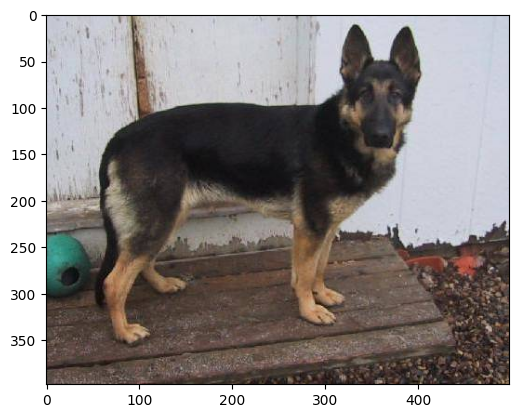

In [5]:
# display dog image

img = mpimg.imread('train/dog.8698.jpg')
plt.imshow(img)

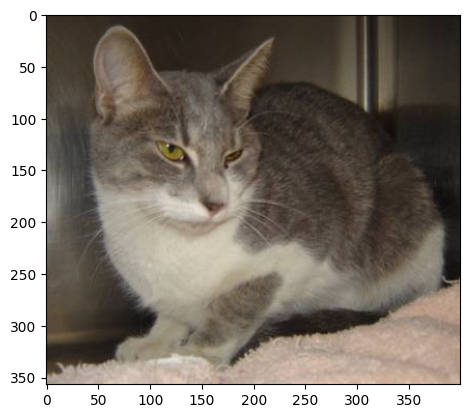

In [6]:
# display cat image

img = mpimg.imread('train/cat.4352.jpg')
plt.imshow(img)

In [7]:
dog_count = 0
for img_file in file_names:
    name = img_file[0:3]
    if name == 'dog':
        dog_count += 1

print('Number of Dog images: ', dog_count)

Number of Dog images:  12500


Resizing the images to a common size

In [8]:
#creating a directory for resized images:
if not os.path.exists('image_resized'):
	os.mkdir('image_resized')

In [9]:
original_folder = 'train/'
resized_folder = 'image_resized/'

for i in range(2000):
    filename = os.listdir(original_folder)[i]
    img_path = original_folder + filename

    img = Image.open(img_path)
    img = img.resize((224,224))
    img = img.convert('RGB')

    newImgPath = resized_folder+filename
    img.save(newImgPath)

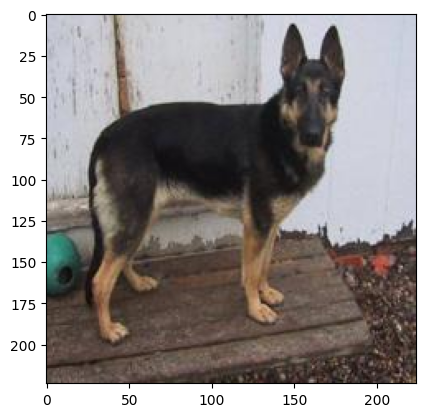

In [10]:
# display resized dog image

img = mpimg.imread('image_resized/dog.8698.jpg')
plt.imshow(img)

**Creating labels for resized images**

Cat --> 0\
Dog --> 1

In [11]:
labels = []
filenames = os.listdir('image_resized/')
for i in range(2000):
    filename = filenames[i]

    label = filename[0:3]

    if label == 'dog':
        labels.append(1)
    else:
        labels.append(0)

In [12]:
filenames

['dog.9562.jpg',
 'cat.3235.jpg',
 'dog.10517.jpg',
 'cat.3521.jpg',
 'cat.5573.jpg',
 'dog.6410.jpg',
 'dog.11413.jpg',
 'dog.10244.jpg',
 'dog.9023.jpg',
 'cat.10978.jpg',
 'cat.8435.jpg',
 'dog.6890.jpg',
 'cat.153.jpg',
 'dog.7063.jpg',
 'cat.451.jpg',
 'dog.11399.jpg',
 'cat.9346.jpg',
 'dog.12407.jpg',
 'dog.6006.jpg',
 'cat.6069.jpg',
 'cat.4293.jpg',
 'dog.12063.jpg',
 'dog.11363.jpg',
 'dog.11441.jpg',
 'cat.5889.jpg',
 'cat.6343.jpg',
 'cat.7656.jpg',
 'cat.12190.jpg',
 'dog.9387.jpg',
 'cat.5072.jpg',
 'cat.2895.jpg',
 'dog.3047.jpg',
 'cat.3561.jpg',
 'dog.5095.jpg',
 'dog.11480.jpg',
 'dog.8670.jpg',
 'cat.7697.jpg',
 'cat.8579.jpg',
 'dog.5513.jpg',
 'dog.4967.jpg',
 'cat.7184.jpg',
 'dog.3997.jpg',
 'dog.1618.jpg',
 'dog.7916.jpg',
 'cat.12456.jpg',
 'dog.5181.jpg',
 'dog.11301.jpg',
 'dog.5133.jpg',
 'cat.6680.jpg',
 'cat.7792.jpg',
 'cat.10225.jpg',
 'cat.4693.jpg',
 'dog.3429.jpg',
 'cat.6819.jpg',
 'cat.3916.jpg',
 'cat.2713.jpg',
 'cat.2795.jpg',
 'dog.9348.jpg',
 '

In [13]:
len(filenames)

2000

In [14]:
labels

[1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,


In [15]:
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 997 1003]


Converting the resized images to numpy arrays

In [16]:
import glob

In [17]:
image_directory = 'image_resized/'
image_extensions = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extensions]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [18]:
dog_cat_images

array([[[[130, 151, 166],
         [107, 128, 143],
         [ 97, 113, 130],
         ...,
         [136, 159, 191],
         [134, 157, 189],
         [127, 150, 182]],

        [[107, 128, 143],
         [ 90, 111, 126],
         [ 89, 105, 122],
         ...,
         [137, 160, 192],
         [135, 158, 190],
         [128, 151, 183]],

        [[ 98, 119, 134],
         [ 88, 109, 124],
         [ 93, 109, 126],
         ...,
         [138, 161, 193],
         [135, 158, 190],
         [128, 151, 183]],

        ...,

        [[ 31,  30,  46],
         [ 32,  31,  47],
         [ 33,  32,  48],
         ...,
         [ 74,  81, 101],
         [ 90,  97, 122],
         [ 88,  95, 122]],

        [[ 33,  33,  47],
         [ 33,  33,  47],
         [ 34,  34,  48],
         ...,
         [ 84,  90, 113],
         [ 89,  96, 123],
         [ 81,  89, 118]],

        [[ 36,  36,  50],
         [ 36,  36,  50],
         [ 36,  36,  50],
         ...,
         [ 84,  92, 115],
        

In [19]:
X = dog_cat_images
Y = np.asarray(labels)

Train Test Split

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y, random_state=2)

In [21]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [22]:
# scaling the data
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [23]:
X_train_scaled

array([[[[0.52156863, 0.45490196, 0.49019608],
         [0.54117647, 0.4745098 , 0.51764706],
         [0.39215686, 0.31764706, 0.39215686],
         ...,
         [0.31764706, 0.31764706, 0.38039216],
         [0.30980392, 0.30980392, 0.37254902],
         [0.30588235, 0.30588235, 0.36862745]],

        [[0.5372549 , 0.47058824, 0.50588235],
         [0.55686275, 0.49411765, 0.5372549 ],
         [0.41176471, 0.34117647, 0.40784314],
         ...,
         [0.31764706, 0.31764706, 0.38039216],
         [0.30980392, 0.30980392, 0.37254902],
         [0.30588235, 0.30588235, 0.36862745]],

        [[0.54509804, 0.49019608, 0.51372549],
         [0.56862745, 0.50980392, 0.54117647],
         [0.42352941, 0.35686275, 0.41176471],
         ...,
         [0.31372549, 0.31372549, 0.37647059],
         [0.30588235, 0.30588235, 0.36862745],
         [0.30196078, 0.30196078, 0.36470588]],

        ...,

        [[0.43529412, 0.38823529, 0.34117647],
         [0.43529412, 0.38823529, 0.34117647]

In [24]:
X_test_scaled

array([[[[0.79215686, 0.67843137, 0.59607843],
         [0.79607843, 0.68235294, 0.6       ],
         [0.80392157, 0.69019608, 0.60784314],
         ...,
         [0.10196078, 0.09803922, 0.10588235],
         [0.11372549, 0.10980392, 0.11764706],
         [0.12156863, 0.11764706, 0.1254902 ]],

        [[0.79607843, 0.68235294, 0.6       ],
         [0.80392157, 0.69019608, 0.60784314],
         [0.80784314, 0.69411765, 0.61176471],
         ...,
         [0.12941176, 0.1254902 , 0.13333333],
         [0.11372549, 0.10980392, 0.11764706],
         [0.10588235, 0.10196078, 0.10980392]],

        [[0.80784314, 0.69411765, 0.61176471],
         [0.80784314, 0.69411765, 0.61176471],
         [0.80784314, 0.69411765, 0.61176471],
         ...,
         [0.14117647, 0.14117647, 0.14117647],
         [0.12156863, 0.12156863, 0.12156863],
         [0.10980392, 0.10980392, 0.10980392]],

        ...,

        [[0.0745098 , 0.14901961, 0.1372549 ],
         [0.05490196, 0.12941176, 0.11764706]

**Building the Neural Network Model using Transfer Learning**

In [25]:
import tensorflow as tf
import tf_keras
import tensorflow_hub as hub

2025-09-23 19:36:03.046648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 19:36:03.080740: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 19:36:03.902163: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [26]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

hub_layer = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

# pretrained_model = tf.keras.layers.Lambda(lambda x: hub_layer(x))

I0000 00:00:1758635464.580969   12687 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4102 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [27]:
num_of_classes = 2 

model = tf_keras.Sequential([
    hub_layer,
    tf_keras.layers.Dense(num_of_classes)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [28]:
model.compile(
    optimizer='adam',
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)

In [29]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5


2025-09-23 19:40:21.731247: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
2025-09-23 19:40:22.163917: I external/local_xla/xla/service/service.cc:163] XLA service 0x785f886b6480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-23 19:40:22.163932: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-09-23 19:40:22.183519: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 5/50 [==>...........................] - ETA: 1s - loss: 0.6126 - acc: 0.6625 

I0000 00:00:1758635722.371129   12768 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 [==============================] - 4s 31ms/step - loss: 0.1924 - acc: 0.9287
Epoch 2/5
50/50 [==============================] - 2s 30ms/step - loss: 0.0640 - acc: 0.9775
Epoch 3/5
50/50 [==============================] - 2s 30ms/step - loss: 0.0474 - acc: 0.9831
Epoch 4/5
50/50 [==============================] - 2s 30ms/step - loss: 0.0371 - acc: 0.9881
Epoch 5/5
50/50 [==============================] - 2s 31ms/step - loss: 0.0293 - acc: 0.9912


In [30]:
score, acc = model.evaluate(X_test_scaled,Y_test)
print('Test Loss = ', score)
print('Test Accuracy = ', acc)

13/13 [==============================] - 1s 32ms/step - loss: 0.0915 - acc: 0.9775
Test Loss =  0.09153915196657181
Test Accuracy =  0.9775000214576721


Building a predictive system

1/1 [==============================] - 0s 20ms/step
[[ 4.993628 -4.076428]]
It's a Cat


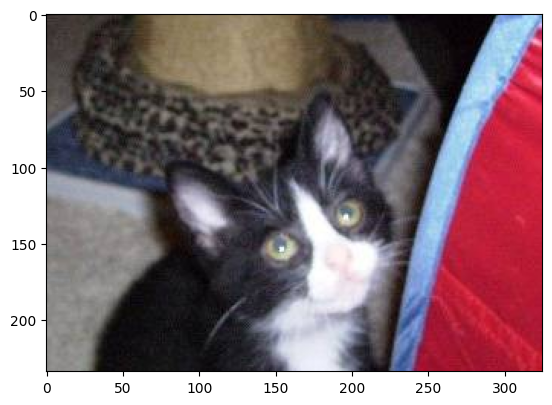

In [32]:
input_image_path = 'test1/8.jpg'

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image,(224,224))

input_image_scaled = input_image_resized / 255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

prediction = model.predict(image_reshaped)
print(prediction)

prediction_label = np.argmax(prediction)

if prediction_label == 0:
    print('It\'s a Cat')
else:
    print('It\'s a Dog')